# Deploying a trained model as an MDI engine: liquid argon over the MolSSI Driver Interface

The [MolSSI Driver Interface](https://github.com/MolSSI-MDI/MDI_Library) (MDI) couples
simulation codes through a small, standardized command protocol: a **driver** (LAMMPS,
SEAMM, or a plain Python script) steers one or more **engines** (quantum-chemistry codes,
ML potentials, ...) by sending commands like `>COORDS` and `<FORCES` over TCP or MPI.

`xnn.common.deploy.MDIEngine` implements the engine side for xnn. It is **model
agnostic**: it talks to the model only through the `AtomicGraph` contract shared by every
family in the library, so a trained MACE, NequIP, Allegro, CACE, SchNet, ANI, PhysNet or
BAMBOO checkpoint is served by the *same* command, `xnn mdi`.

This notebook runs the complete pipeline on the bundled `argon_md` hub dataset:

| stage | tool |
|---|---|
| 1. data | `load_dataset("argon_md")` (xnn hub, ships with the repo) |
| 2. train | `xnn.common.train.Trainer` $\rightarrow$ `runs/mdi_argon/best.pt` |
| 3. serve | `xnn mdi --ckpt best.pt -mdi "-role ENGINE ..."` (engine subprocess) |
| 4. validate | results over the wire $\equiv$ direct `XNNCalculator` evaluation |
| 5. use | **NVE MD of liquid argon**, velocity Verlet in a ~40-line Python driver |

The Python driver below is deliberately minimal so the protocol is fully visible; at the
end we show the one-line change that replaces it with LAMMPS. Requires the `mdi` extra
(`pip install "xnn[mdi]"`).

> **Note:** the MDI library can only be initialized once per process. Restart the kernel
> before re-running the notebook.


## 0. Setup

`float32` on the GPU for training speed; we switch to `float64` for deployment and
dynamics (same convention as the `*_argon_density_md` notebooks).


In [1]:
# silence the expected warnings (TorchScript scripting + e3nn torch.load)
import logging, warnings
logging.getLogger("cuequivariance").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning,
                        message="The TorchScript type system doesn't support")
warnings.filterwarnings("ignore", category=FutureWarning,
                        message="You are using `torch.load` with `weights_only=False`")
warnings.filterwarnings("ignore", message="Use thermalize_momenta")

import sys, time, subprocess
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)
torch.manual_seed(0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
import xnn
print("xnn:", xnn.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "")

xnn: 0.1.0 | device: cuda | NVIDIA A100 80GB PCIe


## 1. Load the `argon_md` hub dataset

Periodic liquid-argon MD frames (400 atoms each) with reference energies, forces and
stress in eV / angstrom, bundled with the repository so this loads offline. The
`config_type=IsolatedAtom` reference frame is dropped by the hub builder; for argon the
isolated-atom energy $E_0$ is zero by construction.


In [2]:
from xnn.common.data import load_dataset

train_structs = load_dataset("argon_md", split="train")
test_structs = load_dataset("argon_md", split="test")

CUTOFF = 6.0
SPECIES = sorted({int(z) for s in train_structs for z in s["atomic_numbers"]})
E0 = {18: 0.0}
n_at = len(train_structs[0]["atomic_numbers"])
print(f"train: {len(train_structs)} frames | test: {len(test_structs)} frames | "
      f"{n_at} atoms/frame | species: {SPECIES}")

train: 200 frames | test: 50 frames | 400 atoms/frame | species: [18]


## 2. Train a small MACE

Same architecture and optimizer settings as `../gnn/mace/mace_argon_train_test.ipynb`
(2 interactions, 32 channels, $\ell_\mathrm{max}=3$, $L_\mathrm{max}=1$, per-atom
energy + force loss), but only 30 epochs: deployment, not accuracy, is the point here.
The `Trainer` writes the best-validation checkpoint to `runs/mdi_argon/best.pt`; that
single file (weights **and** config) is everything the MDI engine needs.


In [3]:
from xnn.common.config import from_dict
from xnn.common.data import AtomicDataset
from xnn.common.train import Trainer

# average number of neighbours (MACE message normalization), from a few frames
probe = AtomicDataset(train_structs[:10], CUTOFF)
graphs = [probe[i] for i in range(len(probe))]
LAMBDA = float(sum(g.num_edges for g in graphs) / sum(g.num_nodes for g in graphs))
print(f"avg neighbours = {LAMBDA:.2f}")

core = from_dict({
    "model": {"name": "mace", "cutoff": CUTOFF, "n_features": 32, "n_interactions": 2,
              "n_rbf": 8, "species": SPECIES, "max_ell": 3, "max_L": 1, "correlation": 3,
              "hidden_irreps": "32x0e+32x1o", "MLP_irreps": "16x0e",
              "avg_num_neighbors": LAMBDA, "atomic_energies": [E0[z] for z in SPECIES]},
    "data": {"batch_size": 10},
    "optim": {"lr": 0.01, "weight_decay": 5e-7, "epochs": 30,
              "energy_weight": 1.0, "force_weight": 100.0, "scheduler": "plateau"},
    "device": DEVICE, "seed": 0, "output_dir": "runs/mdi_argon",
})

rng = np.random.default_rng(0)
idx = rng.permutation(len(train_structs))
train_set = AtomicDataset([train_structs[i] for i in idx[:180]], CUTOFF)
val_set = AtomicDataset([train_structs[i] for i in idx[180:]], CUTOFF)

t0 = time.time()
Trainer(core, train_set, val_set).fit()
print(f"\ntrained {core.optim.epochs} epochs in {time.time()-t0:.0f} s "
      f"-> {core.output_dir}/best.pt")

avg neighbours = 16.96


epoch    0 | train loss 1.6979e-01 | val loss 1.1223e-01


epoch    1 | train loss 4.2205e-02 | val loss 7.2734e-02


epoch    2 | train loss 2.1054e-02 | val loss 3.4279e-02


epoch    3 | train loss 9.7247e-03 | val loss 1.0851e-02


...

epoch   25 | train loss 6.7053e-04 | val loss 8.2944e-04


epoch   26 | train loss 6.8954e-04 | val loss 8.7361e-04


epoch   27 | train loss 9.5956e-04 | val loss 8.0108e-04


epoch   28 | train loss 1.3346e-03 | val loss 3.1894e-03


epoch   29 | train loss 1.4704e-03 | val loss 1.0907e-03

trained 30 epochs in 94 s -> runs/mdi_argon/best.pt


## 3. Reload the checkpoint and sanity-check on the test set

We reload `best.pt` exactly the way any deployment consumer does (and the way
`MDIEngine.from_checkpoint` does internally): rebuild with `build_model` from the stored
config, wrap in `ForceStressOutput`, load the state dict. A quick pass over ten test
frames confirms the 30-epoch model is a physically usable argon potential before we
serve it.


10 test frames: energy MAE 13.34 meV/atom | force RMSE 2.1 meV/A


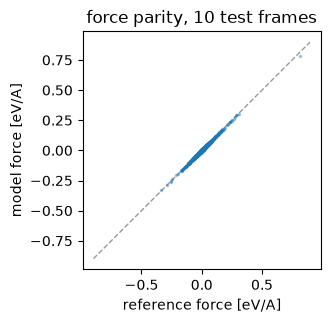

In [4]:
torch.set_default_dtype(torch.float64)   # deployment and dynamics in float64

from ase import Atoms
from xnn.common.models import build_model, ForceStressOutput
from xnn.common.deploy import XNNCalculator

ckpt = torch.load("runs/mdi_argon/best.pt", map_location="cpu", weights_only=False)
model = ForceStressOutput(build_model(ckpt["cfg"].model), compute_stress=True).double()
model.load_state_dict(ckpt["model"])
calc = XNNCalculator(model, cutoff=ckpt["cfg"].model.cutoff, device=DEVICE)

de, df = [], []
for s in test_structs[:10]:
    at = Atoms(numbers=s["atomic_numbers"], positions=s["pos"], cell=s["cell"], pbc=True)
    at.calc = calc
    de.append((at.get_potential_energy() - s["energy"]) / len(at))
    df.append((at.get_forces() - s["forces"]).ravel())
de, df = np.array(de), np.concatenate(df)
print(f"10 test frames: energy MAE {np.abs(de).mean()*1000:.2f} meV/atom | "
      f"force RMSE {np.sqrt((df**2).mean())*1000:.1f} meV/A")

f_ref = np.concatenate([s["forces"].ravel() for s in test_structs[:10]])
f_mod = f_ref + df
pick = np.random.default_rng(0).choice(f_ref.size, 2000, replace=False)
lim = np.abs(f_ref[pick]).max() * 1.1
fig, ax = plt.subplots(figsize=(3.4, 3.4))
ax.plot([-lim, lim], [-lim, lim], "--", color="0.6", lw=1)
ax.plot(f_ref[pick], f_mod[pick], ".", ms=3, alpha=0.35, color="#1f77b4")
ax.set_xlabel("reference force [eV/A]"); ax.set_ylabel("model force [eV/A]")
ax.set_title("force parity, 10 test frames"); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 4. Serve the checkpoint as an MDI engine

The engine runs as a **separate process**, exactly as it would next to LAMMPS. The
subprocess below is literally the `xnn mdi` console command:

```bash
xnn mdi --ckpt runs/mdi_argon/best.pt --device cuda --dtype float64 \
    -mdi "-role ENGINE -name xnn -method TCP -port 8021 -hostname localhost"
```

`--dtype float64` upcasts the float32-trained weights so the NVE integration below is
not limited by single precision. Order matters for TCP: the **driver initializes first**
(it owns the listening socket), then the engine is launched and connects.

The driver side is the ~40-line class below. It works in ASE units (angstrom / eV) and
converts to MDI atomic units (Bohr / Hartree) at the wire, mirroring what the engine
does on its side. We convert with the engine's own public constants
(`xnn.common.deploy.mdi_engine.BOHR_TO_ANGSTROM` / `HARTREE_TO_EV`, CODATA 2018) so the
round trip is bit-clean; a driver with a different CODATA vintage (e.g. `ase.units`,
CODATA 2014) would differ at the physically irrelevant 1e-8 relative level.


In [5]:
import mdi
from xnn.common.deploy.mdi_engine import (   # the engine's exact wire constants
    BOHR_TO_ANGSTROM as Bohr, HARTREE_TO_EV as Hartree)


class MDIDriver:
    """Minimal MDI driver speaking ASE units (angstrom / eV) to any MDI engine."""

    def __init__(self, port):
        mdi.MDI_Init(f"-role DRIVER -name driver -method TCP -port {port}")
        self.comm = None
        self.natoms = 0

    def accept(self):
        """Block until an engine connects."""
        self.comm = mdi.MDI_Accept_Communicator()

    def send_system(self, atomic_numbers, cell):
        n = self.natoms = len(atomic_numbers)
        mdi.MDI_Send_Command(">NATOMS", self.comm)
        mdi.MDI_Send(n, 1, mdi.MDI_INT, self.comm)
        mdi.MDI_Send_Command(">ELEMENTS", self.comm)
        mdi.MDI_Send([int(z) for z in atomic_numbers], n, mdi.MDI_INT, self.comm)
        mdi.MDI_Send_Command(">CELL", self.comm)
        mdi.MDI_Send((np.asarray(cell) / Bohr).flatten(), 9, mdi.MDI_DOUBLE, self.comm)

    def send_positions(self, pos):
        mdi.MDI_Send_Command(">COORDS", self.comm)
        mdi.MDI_Send((np.asarray(pos) / Bohr).flatten(), 3 * self.natoms,
                     mdi.MDI_DOUBLE, self.comm)

    def energy(self):
        mdi.MDI_Send_Command("<ENERGY", self.comm)
        return mdi.MDI_Recv(1, mdi.MDI_DOUBLE, self.comm) * Hartree

    def forces(self):
        mdi.MDI_Send_Command("<FORCES", self.comm)
        f = mdi.MDI_Recv(3 * self.natoms, mdi.MDI_DOUBLE, self.comm)
        return np.asarray(f).reshape(-1, 3) * (Hartree / Bohr)

    def stress(self):
        mdi.MDI_Send_Command("<STRESS", self.comm)
        s = mdi.MDI_Recv(9, mdi.MDI_DOUBLE, self.comm)
        return np.asarray(s).reshape(3, 3) * (Hartree / Bohr**3)

    def exit(self):
        mdi.MDI_Send_Command("EXIT", self.comm)

In [6]:
PORT = 8021
driver = MDIDriver(PORT)                 # 1. driver listens on the port

engine_log = open("runs/mdi_argon/engine.log", "w")
engine = subprocess.Popen(               # 2. engine loads the checkpoint and connects
    [sys.executable, "-W", "ignore", "-m", "xnn.common.deploy.mdi_engine",
     "--ckpt", "runs/mdi_argon/best.pt", "--device", DEVICE, "--dtype", "float64",
     "-mdi", f"-role ENGINE -name xnn -method TCP -port {PORT} -hostname localhost"],
    stdout=engine_log, stderr=subprocess.STDOUT)

t0 = time.time()
driver.accept()                          # 3. blocks until the engine is up
print(f"engine connected after {time.time()-t0:.1f} s (model load + TCP handshake)")

engine connected after 2.8 s (model load + TCP handshake)


## 5. Validate: results over the wire $\equiv$ direct evaluation

One test frame is pushed through both paths: the MDI round trip
(angstrom $\rightarrow$ Bohr $\rightarrow$ engine $\rightarrow$ Hartree $\rightarrow$ eV)
and the in-process `XNNCalculator` from section 3. The two must agree to floating-point
precision. The only convention difference is the stress sign: MDI uses the pressure-like
sign, negated relative to the $\sigma = V^{-1}\,\partial E/\partial\epsilon$ tensor
that ASE reports.


In [7]:
s0 = test_structs[0]
driver.send_system(s0["atomic_numbers"], s0["cell"])
driver.send_positions(s0["pos"])
e_mdi, f_mdi, st_mdi = driver.energy(), driver.forces(), driver.stress()

at = Atoms(numbers=s0["atomic_numbers"], positions=s0["pos"], cell=s0["cell"], pbc=True)
at.calc = calc
e_dir, f_dir, s_dir = at.get_potential_energy(), at.get_forces(), at.get_stress()

s_mdi_voigt = -np.array([st_mdi[0, 0], st_mdi[1, 1], st_mdi[2, 2],
                         st_mdi[1, 2], st_mdi[0, 2], st_mdi[0, 1]])

print(f"energy  MDI {e_mdi:.8f} eV | direct {e_dir:.8f} eV | "
      f"diff {abs(e_mdi - e_dir):.1e} eV")
print(f"forces  max |MDI - direct| = {np.abs(f_mdi - f_dir).max():.1e} eV/A")
print(f"stress  max |MDI - direct| = {np.abs(s_mdi_voigt - s_dir).max():.1e} eV/A^3 "
      f"(after undoing the MDI sign convention)")
print(f"vs dataset reference: dE = {(e_mdi - s0['energy'])/len(at)*1000:+.2f} meV/atom, "
      f"force RMSE = {np.sqrt(((f_mdi - s0['forces'])**2).mean())*1000:.1f} meV/A")
assert abs(e_mdi - e_dir) < 1e-8
assert np.abs(f_mdi - f_dir).max() < 1e-9

energy  MDI -28.76609863 eV | direct -28.76609863 eV | diff 1.1e-14 eV
forces  max |MDI - direct| = 2.0e-14 eV/A
stress  max |MDI - direct| = 7.0e-18 eV/A^3 (after undoing the MDI sign convention)
vs dataset reference: dE = +5.68 meV/atom, force RMSE = 1.3 meV/A


## 6. Use it: NVE molecular dynamics driven over MDI

The driver now plays the role LAMMPS would play: it owns positions and velocities and
integrates velocity Verlet, while **every force evaluation happens in the engine
process**. Per step only `>COORDS` is re-sent; the engine keeps elements and cell from
section 5 and lazily re-evaluates once per geometry, so the paired `<FORCES` + `<ENERGY`
requests cost a single model call. Positions are sent unwrapped: the engine's neighbor
list handles coordinates outside the box.

Liquid argon at $T \approx 85$ K with a 5 fs timestep (as in the
`*_argon_density_md` notebooks), 240 steps = 1.2 ps. NVE has no thermostat, so the
initial velocities are drawn at **twice** the target temperature: during the first
~0.2 ps roughly half of the fresh kinetic energy repartitions into potential energy
(equipartition), leaving the run fluctuating near the target.


In [8]:
from ase import units as u
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

T_K, DT, N_STEPS = 85.0, 5 * u.fs, 240

at = Atoms(numbers=s0["atomic_numbers"], positions=s0["pos"], cell=s0["cell"], pbc=True)
# 2 x T: half the kinetic energy flows into potential during NVE equilibration
MaxwellBoltzmannDistribution(at, temperature_K=2 * T_K, rng=np.random.default_rng(0))
Stationary(at)

pos, vel = at.get_positions(), at.get_velocities()
m, N = at.get_masses()[:, None], len(at)

epot, ekin = np.empty(N_STEPS + 1), np.empty(N_STEPS + 1)
driver.send_positions(pos)
f = driver.forces()
epot[0], ekin[0] = driver.energy(), 0.5 * (m * vel**2).sum()

t0 = time.time()
for step in range(1, N_STEPS + 1):
    vel += 0.5 * DT * f / m
    pos += DT * vel
    driver.send_positions(pos)
    f = driver.forces()
    vel += 0.5 * DT * f / m
    epot[step], ekin[step] = driver.energy(), 0.5 * (m * vel**2).sum()
wall = time.time() - t0
print(f"{N_STEPS} NVE steps ({N_STEPS * DT / u.fs / 1000:.1f} ps) in {wall:.0f} s = "
      f"{N_STEPS / wall:.1f} steps/s ({N * N_STEPS / wall:.0f} atom-steps/s)")

240 NVE steps (1.2 ps) in 55 s = 4.3 steps/s (1735 atom-steps/s)


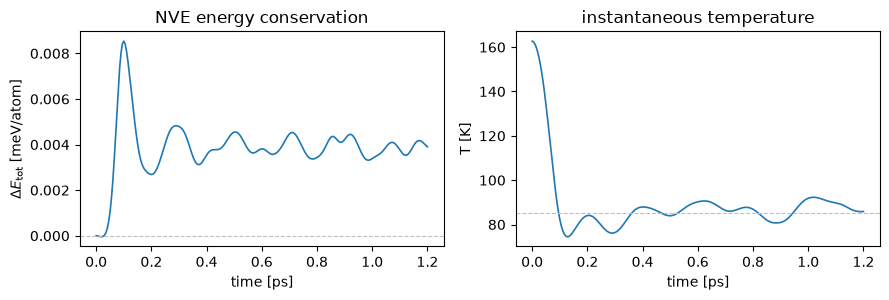

max |E_tot(t) - E_tot(0)| = 0.009 meV/atom over 1.2 ps | <T> (last half) = 87.3 K


In [9]:
t_ps = np.arange(N_STEPS + 1) * DT / u.fs / 1000
etot = epot + ekin
temp = 2 * ekin / (3 * N * u.kB)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.1))
ax[0].plot(t_ps, (etot - etot[0]) / N * 1000, color="#1f77b4", lw=1.2)
ax[0].axhline(0, color="0.75", lw=0.8, ls="--")
ax[0].set_xlabel("time [ps]")
ax[0].set_ylabel("$\\Delta E_\\mathrm{tot}$ [meV/atom]")
ax[0].set_title("NVE energy conservation")
ax[1].plot(t_ps, temp, color="#1f77b4", lw=1.2)
ax[1].axhline(T_K, color="0.75", lw=0.8, ls="--")
ax[1].set_xlabel("time [ps]"); ax[1].set_ylabel("T [K]")
ax[1].set_title("instantaneous temperature")
plt.tight_layout(); plt.show()

drift = np.abs(etot - etot[0]).max() / N * 1000
print(f"max |E_tot(t) - E_tot(0)| = {drift:.3f} meV/atom over {t_ps[-1]:.1f} ps | "
      f"<T> (last half) = {temp[N_STEPS // 2:].mean():.1f} K")

## 7. Shut the engine down


In [10]:
driver.exit()
engine.wait(timeout=60)
engine_log.close()
print(f"engine exited with code {engine.returncode}\n")
print("--- runs/mdi_argon/engine.log (tail) ---")
print("\n".join(open("runs/mdi_argon/engine.log").read().splitlines()[-5:]))

engine exited with code 0

--- runs/mdi_argon/engine.log (tail) ---
INFO:__main__:MDI connection established
INFO:__main__:received 400 atoms, elements [18]
INFO:__main__:step 100: avg 141.9 ms/step
INFO:__main__:step 200: avg 108.5 ms/step
INFO:__main__:engine finished: 242 calculations, avg 102.4 ms/step


## Where to go from here

**Drive it from LAMMPS instead of Python.** The engine side does not change; only the
launch method does (MPI instead of TCP, `mpi4py` required):

```bash
mpirun -np 1 xnn mdi --ckpt runs/mdi_argon/best.pt --device cuda:0 --dtype float64 \
        -mdi "-role ENGINE -name xnn -method MPI" \
    : -np 4 lmp -mdi "-role DRIVER -name LAMMPS -method MPI" -in in.argon
```

with `fix mdi/qm` (or the `mdi` fix family) on the LAMMPS side. The same applies to any
other MDI driver, e.g. SEAMM's LAMMPS step.

**Serve a different model.** Nothing here is MACE specific: point `--ckpt` at any
`best.pt` produced by the xnn `Trainer` (NequIP, Allegro, CACE, SchNet, ANI, PhysNet,
BAMBOO, with or without the LES long-range wrapper) and the engine rebuilds it from the
stored config and serves it through the identical protocol.

**Embed it.** `MDIEngine` is a plain class
(`from xnn.common.deploy import MDIEngine`); `MDIEngine.from_checkpoint(path)` plus
`engine.run(mdi_options)` reproduces the CLI inside your own launcher, and
`MDIEngine(model, cutoff)` accepts any in-memory model that follows the `AtomicGraph`
contract.
